## 3.8 연습문제

### 1. MNIST 데이터셋으로 분류기를 만들어 테스트 세트에서 97%의 정확도를 달성해보자.
* KNeighborsClassifier가 이 작업에 잘 맞다. 좋은 하이퍼파라미터 값만 찾으면 된다. 
* weight와 n_neighbors 하이퍼파라미터로 그리드 탐색을 실행해보자.
* https://m.blog.naver.com/bestinall/221760380344

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [2]:
import sys
assert sys.version_info >= (3, 5)

# 사이킷런 ≥0.20 필수
import sklearn
assert sklearn.__version__ >= "0.20"

# 공통 모듈 임포트
import numpy as np
import os

In [3]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
# MNIST 데이터
X=mnist["data"]

# MNIST 타겟
y=mnist["target"]
y=y.astype(np.uint8) # 텍스트를 정수형으로

In [5]:
# 데이터를 조사하기 전에 테스트 세트를 분리하고 시작한다.
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [6]:
# KNeighborsClassifier import

from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

In [7]:
# Train Model
kn.fit(X_train, y_train)

KNeighborsClassifier()

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 5, 7]}]

# GridSearchCV로 best parameter 찾기
kn_grid = KNeighborsClassifier()
grid_search = GridSearchCV(kn_grid, param_grid, scoring='accuracy', cv=5,verbose=3, n_jobs=4)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=4,
             param_grid=[{'n_neighbors': [3, 5, 7],
                          'weights': ['uniform', 'distance']}],
             scoring='accuracy', verbose=3)

In [9]:
# 최적의 매개변수와 점수
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best Score: 0.9711166666666665


In [10]:
from sklearn.metrics import accuracy_score

y_pred = grid_search.predict(X_test)
accuracy_score(y_test, y_pred)

0.9717

---

### 2. MNIST 이미지를 (왼, 오른, 위, 아래) 어느 방향이든 움직일 수 있는 함수를 만들어보자. 
그런 다음 훈련세트에 있는 각 이미지에 대해 네 개의 이동된 복사본(방향마다 한개씩)을 만들어 훈련세트에 추가한다. 

마지막으로 이 확장된 데이터셋에서 앞에서 찾은 최선의 모델을 훈련시키고 테스트 세트에서 정확도를 측정해보자. 
* 이처럼 인위적으로 훈련세트를 늘리는 기법을 데이터 증식 또는 훈련세트 확장이라고 한다.

In [3]:
import numpy as np
from scipy.ndimage import shift
import matplotlib.pyplot as plt

In [12]:
# shift 함수 정의
def shift_image(image, direction, shift_size=5):
    """
    이미지를 지정된 방향으로 shift_size 만큼 이동한다
    -image; 입력 이미지(numpy array)
    -direction; 'up','down','left','right'
    -shift_size; 이동할 pixel(default=5)
    
    return; shifted image
    """
    image = image.reshape((28,28))
    if direction == 'up':
        return shift(image, shift=[-shift_size, 0], cval=0).reshape([-1])
    elif direction =='down':
        return shift(image, shift=[shift_size, 0], cval=0).reshape([-1])
    elif direction=='left':
        return shift(image, shift=[0,-shift_size], cval=0).reshape([-1])
    elif direction=='right':
        return shift(image, shift=[0, shift_size], cval=0).reshape([-1])
    else:
        raise ValueError("Invalid direction, please choose from 'up','down','left','right'")

In [13]:
# example; shifting images
ex_image = X_train[10000]
shifted_image_up=shift_image(ex_image, 'up')
shifted_image_down=shift_image(ex_image, 'down')
shifted_image_left=shift_image(ex_image, 'left')
shifted_image_right=shift_image(ex_image, 'right')

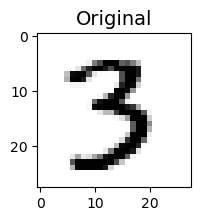

In [21]:
plt.figure(figsize=(12,2))
plt.title("Original", fontsize=14)
plt.imshow(ex_image.reshape(28, 28), interpolation="nearest", cmap="Greys")

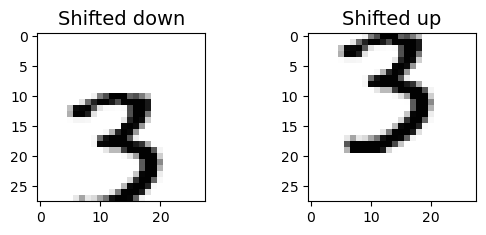

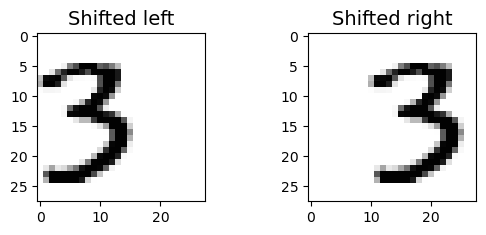

In [22]:
plt.subplot(221)
plt.title("Shifted down", fontsize=14)
plt.imshow(shifted_image_down.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.subplot(222)
plt.title("Shifted up", fontsize=14)
plt.imshow(shifted_image_up.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.show()
plt.subplot(223)
plt.title("Shifted left", fontsize=14)
plt.imshow(shifted_image_left.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.subplot(224)
plt.title("Shifted right", fontsize=14)
plt.imshow(shifted_image_right.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.show()

In [23]:
# 모든 Train 데이터에 대해 데이터 증식
X=X.reshape(-1,28,28).astype(np.uint8)
y=y.astype(np.uint8)

augmented_images=[]
augmented_labels=[]
directions=['up','down','left','right']

for direction in directions:
    for i in range(len(X)):
        shifted_image = shift_image(X[i], direction)
        augmented_images.append(shifted_image)
        augmented_labels.append(y[i])

In [24]:
# 기존 데이터와 증식된 데이터를 합치기
X_augmented = np.vstack([X.reshape(len(X), -1), np.array(augmented_images)])
y_augmented = np.hstack([y, np.array(augmented_labels)])

In [25]:
70000+70000*4

350000

In [26]:
# 데이터셋 섞기
shuffled_indices = np.random.permutation(len(X_augmented))
X_augmented = X_augmented[shuffled_indices]
y_augmented = y_augmented[shuffled_indices]

In [27]:
# 테스트셋 구분하기; Stratified Sampling을 사용해 train과 test 데이터셋으로 나누기
from sklearn.model_selection import train_test_split

X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(X_augmented, y_augmented, test_size=0.2, stratify=y_augmented, random_state=42)

In [29]:
# 기존 모델로 새로운 데이터셋 이용해서 학습
kn_clf = KNeighborsClassifier(weights='distance', n_neighbors=3)
kn_clf.fit(X_train_aug, y_train_aug)

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [30]:
# 기존은 0.9717
# 새로운 예측
y_pred_aug = kn_clf.predict(X_test_aug)
accuracy_score(y_test_aug, y_pred_aug)

0.9735

0.2% 정확도 상승

---

### 3. 타이타닉 데이터셋에 도전해보자.

승객의 나이, 성별, 승객 등급, 승선 위치 같은 속성을 기반으로 하여 승객의 생존 여부를 예측하는 것이 목표입니다.

In [4]:
# 데이터 로드
import os
import urllib.request

TITANIC_PATH = os.path.join("datasets", "titanic")
DOWNLOAD_URL = "https://raw.githubusercontent.com/rickiepark/handson-ml2/master/datasets/titanic/"

def fetch_titanic_data(url=DOWNLOAD_URL, path=TITANIC_PATH):
    if not os.path.isdir(path):
        os.makedirs(path)
    for filename in ("train.csv", "test.csv"):
        filepath = os.path.join(path, filename)
        if not os.path.isfile(filepath):
            print("Downloading", filename)
            urllib.request.urlretrieve(url + filename, filepath)

fetch_titanic_data()   

In [26]:
import pandas as pd

def load_titanic_data(filename, titanic_path=TITANIC_PATH):
    csv_path = os.path.join(titanic_path, filename)
    return pd.read_csv(csv_path)

In [82]:
train_data = load_titanic_data("train.csv")
test_data = load_titanic_data("test.csv")

데이터는 이미 훈련 세트와 테스트 세트로 분리되어 있습니다. 그러나 테스트 데이터는 레이블을 가지고 있지 않습니다: 훈련 데이터를 이용하여 가능한 최고의 모델을 만들고 테스트 데이터에 대한 예측을 캐글(Kaggle)에 업로드하여 최종 점수를 확인하는 것이 목표입니다.

In [83]:
print("shape of train data: ", train_data.shape)
print("shape of test data: ", test_data.shape)

shape of train data:  (891, 12)
shape of test data:  (418, 11)


In [84]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* train_data에는 총 891개의 entries가 있다
* 이중 Null 값을 가지는 Attribute는
    * Age attribute에서 177개의 Null 값 존재
    * Cabin attribute에서 687개의 Null 값 존재
    * Embarked attribute에서 2개의 Null 값 존재. 

In [85]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [86]:
train_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


속성은 다음과 같은 의미를 가집니다:
* **PassengerId**: 각 승객의 고유 식별자.
* **Survived**: 타깃입니다. 0은 생존하지 못한 것이고 1은 생존을 의미합니다.
* **Pclass**: 승객 등급. 1, 2, 3등석.
* **Name**, **Sex**, **Age**: 이름 그대로 의미입니다.
* **SibSp**: 함께 탑승한 형제, 배우자의 수.
* **Parch**: 함께 탑승한 자녀, 부모의 수.
* **Ticket**: 티켓 아이디
* **Fare**: 티켓 요금 (파운드)
* **Cabin**: 객실 번호
* **Embarked**: 승객이 탑승한 곳. C(Cherbourg), Q(Queenstown), S(Southampton)

In [87]:
# PassengerId 를 index로 만들자.
train_data = train_data.set_index("PassengerId")
test_data = test_data.set_index("PassengerId")

In [91]:
train_data["Age"].median()

28.0

In [92]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


결측치 처리는 파이프라인을 사용할거야. 각 특성마다 어떤 방법을 사용하는것이 좋을까..
* Cabin 값은 일단은 무시한다.
* Age는 평균을 사용하자

* Name과 Tickets는 숫자로 바꾸기 조금 애매하니까 일단 무시

In [93]:
train_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

범주형 특성들을 살펴보자

In [101]:
train_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [102]:
train_data["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [106]:
train_data["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [107]:
train_data["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

|수치형 특성들을 위한 pipleline을 만들자.

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), #결측치; 중앙값으로
    ("scaler", StandardScaler())                   #표준화
])

| 범주형 특성을 위한 pipeline을 만들자.

In [113]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")), #결측치; 최빈값으로 
    ('cat_encoder', OneHotEncoder(sparse=False))          #원핫인코딩
])

In [116]:
# 숫자와 범주형 파이프라인을 연결한다.

from sklearn.compose import ColumnTransformer
# 열마다 다른 데이터 전처리 방법을 적용한다.

num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

preprocess_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

이제 원본 데이터를 받아 머신러닝 모델에 주입할 숫자 입력 특성을 출력하는 전처리 파이프라인을 만들 수 있다.

In [117]:
X_train = preprocess_pipeline.fit_transform(
    train_data[num_attribs+cat_attribs])

X_train

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[-0.56573646,  0.43279337, -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.66386103,  0.43279337, -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [-0.25833709, -0.4745452 , -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.1046374 ,  0.43279337,  2.00893337, ...,  0.        ,
         0.        ,  1.        ],
       [-0.25833709, -0.4745452 , -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.20276197, -0.4745452 , -0.47367361, ...,  0.        ,
         1.        ,  0.        ]])

In [118]:
y_train = train_data["Survived"]

이제 분류기를 훈련시킬 수 있다
* RandomForestClassifier를 사용해보자

In [120]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [121]:
X_test = preprocess_pipeline.transform(test_data[num_attribs + cat_attribs])

In [122]:
y_pred = forest_clf.predict(X_test)

In [123]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
forest_scores.mean()

0.8092759051186016

* DesicionTreeRegressor을 적용해보자

In [126]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [128]:
tree_score = cross_val_score(tree_reg, X_train, y_train, cv=10)
tree_score.mean()

0.10070473571763047

* SVC를 적용해보자

In [124]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
svm_scores.mean()

0.8249313358302123

좋네요! 이 모델이 훨씬 나아보입니다.

하지만 10 폴드 교차 검증에 대한 평균 정확도를 보는 대신 모델에서 얻은 10개의 점수를 1사분위, 3사분위를 명료하게 표현해주는 상자 수염 그림(box-and-whisker) 그래프를 만들어 보겠습니다. `boxplot()` 함수는 이상치(플라이어(flier)라고 부릅니다)를 감지하고 수염 부분에 이를 포함시키지 않습니다. 1사분위가 $Q_1$이고 3사분위가 $Q_3$이라면 사분위수 범위는 $IQR = Q_3 - Q_1$가 됩니다(이 값이 박스의 높이가 됩니다). $Q_1 - 1.5 \times IQR$ 보다 낮거나 $Q3 + 1.5 \times IQR$ 보다 높은 점수는 이상치로 간주됩니다.

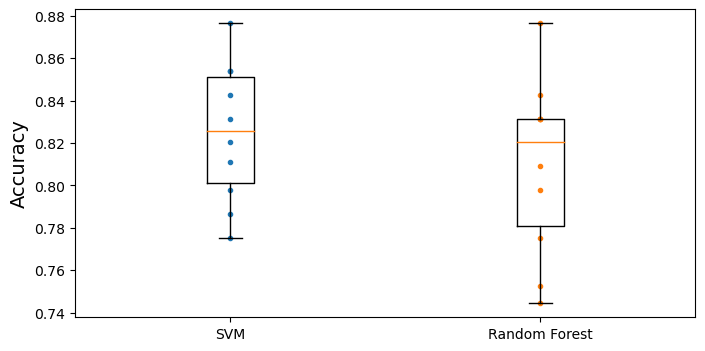

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")

plt.boxplot([svm_scores, forest_scores], labels=("SVM","Random Forest"))
plt.ylabel("Accuracy", fontsize=14)
plt.show()

랜덤 포레스트 분류기가 10개의 폴드 중 하나에서 매우 높은 점수를 얻었지만 넓게 퍼져 있기 때문에 전체적인 평균 점수는 낮습니다. 따라서 SVM 분류기가 일반화를 더 잘하는 것 같습니다.

이 결과를 더 향상시키려면:
* 교차 검증과 그리드 탐색을 사용하여 더 많은 모델을 비교하고 하이퍼파라미터를 튜닝하세요.
* 특성 공학을 더 시도해 보세요, 예를 들면:
  * 수치 특성을 범주형 특성으로 바꾸어 보세요: 예를 들어, 나이대가 다른 경우 다른 생존 비율을 가질 수 있습니다(아래 참조). 그러므로 나이 구간을 범주로 만들어 나이 대신 사용하는 것이 도움이 될 수 있스니다. 비슷하게 생존자의 30%가 혼자 여행하는 사람이기 때문에 이들을 위한 특별한 범주를 만드는 것이 도움이 될 수 있습니다(아래 참조).
  * **SibSp**와 **Parch**을 이 두 특성의 합으로 바꿉니다.
  * **Survived** 특성과 관련된 이름을 구별해 보세요.
  * **Cabin** 열을 사용하세요. 예를 들어 첫 글자를 범주형 속성처럼 다룰 수 있습니다.

---

### 4. 스팸분류기를 만들어보자.(**Hard**)

---